In [9]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader , Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [10]:
#check for gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using devie: {device}")

Using devie: cuda


In [11]:
torch.manual_seed(42)

In [12]:
df = pd.read_csv('fashion-mnist_train.csv')

In [13]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
df['label'].value_counts()

,count
label,
2,6000
9,6000
6,6000
0,6000
3,6000
4,6000
5,6000
8,6000
7,6000


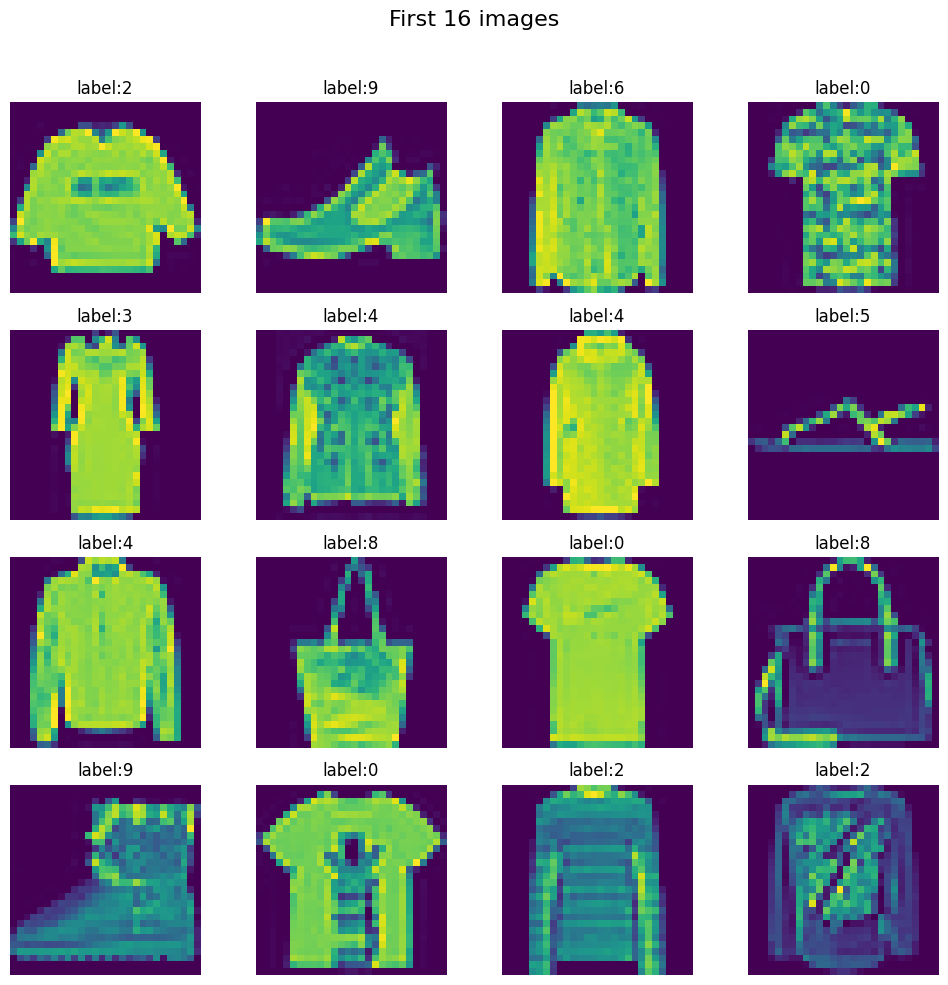

In [15]:
#creating a 4x4 grid layout
fig , axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('First 16 images',fontsize=16)

#plot the first 16 images from the dataset
for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28) #reshaping image
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'label:{df.iloc[i,0]}')#show the label

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [16]:
#sklearn automatically handles pandas dataframe
#but pytorch requires explicit conversion to numpy arrays and tensors
#pytorch always expect the input tensors to be in float and output label to be long

In [17]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [18]:
x.dtype

dtype('int64')

In [19]:
y.dtype

dtype('int64')

In [20]:
x.shape

(60000, 784)

In [21]:
#pytorch always expects input as tensor

In [22]:
# convert input to float32 to match model parameters and avoid dtype mismatch errors

In [23]:
x = torch.tensor(x,dtype=torch.float32)
y = torch.tensor(y,dtype=torch.long)

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
x_train.dtype

torch.float32

In [26]:
y_train.dtype

torch.int64

In [27]:
x_train=x_train/255.0
x_test=x_test/255.0

In [28]:
#create customdataset class
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = features
    self.labels = torch.tensor(labels,dtype=torch.long)
  def __len__(self):
    return self.features.shape[0]
  def __getitem__(self, index):
    return self.features[index],self.labels[index]

In [29]:
traindataset = CustomDataset(x_train,y_train)
testdataset = CustomDataset(x_test,y_test)

/tmp/ipykernel_3111/3229686613.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels,dtype=torch.long)


In [30]:
train_load = DataLoader(traindataset,batch_size=32,shuffle=True,pin_memory = True)
test_load = DataLoader(testdataset,batch_size=32,shuffle=False,pin_memory = True)

In [31]:
traindataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
         0.5333, 0.0000, 0.0

In [32]:
x_train.dtype

torch.float32

In [33]:
#define NN class
#No need to mention about activation function of final output layer because with help of loss function it will figure out what activation function it is
class mynn(nn.Module):
  def __init__(self,num_features):

    super().__init__()
    self.linear = nn.Linear(num_features,128)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(128,64)
    self.linear3 = nn.Linear(64,10)

  def forward(self,features):
    out=self.linear(features)
    out=self.relu(out)
    out=self.linear2(out)
    out=self.relu(out)
    out=self.linear3(out)

    return out


In [34]:
epochs = 100
learning_rate = 0.1

In [35]:
#If loss has "Logits" → NO activation
#If loss doesn’t → YOU add activation

In [36]:
#instiate model
#need to switch the model from cpu to gpu after instializing
model = mynn(x_train.shape[1])
model = model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [37]:
len(train_load)

1500

In [38]:
# Do not apply sigmoid when using BCEWithLogitsLoss,
# as it internally applies sigmoid for numerical stability

In [39]:
# CrossEntropyLoss uses labels as indices to pick correct class
# from logits and computes loss for each sample

In [40]:
# -------------------- LOSS FUNCTIONS SUMMARY --------------------

# Binary Classification (BCELoss):
# - Model output shape: (batch_size, 1)
# - Labels shape: (batch_size,) → must reshape to (batch_size,1)
# - BCELoss requires prediction and target shapes to match exactly
# - Sigmoid activation must be applied before loss

# Better option:
# - Use BCEWithLogitsLoss → no need for sigmoid (handled internally)

# Multi-class Classification (CrossEntropyLoss):
# - Model output shape: (batch_size, num_classes)
# - Labels shape: (batch_size,) → class indices
# - No need to reshape labels
# - No need to apply softmax (handled internally)

# Internal working of CrossEntropyLoss:
# - Applies softmax to logits
# - Uses label as index to pick correct class
# - Computes -log(probability_of_correct_class)
# - Averages loss over batch

# Key Difference:
# - BCELoss → direct value comparison → shapes must match
# - CrossEntropyLoss → index-based selection → shapes differ

In [41]:
#.item converts tensor into scalar only works for 1d tensor
#we move batch_features and batch_labels to the device(GPU) to ensure all computations happen on the same device,avoiding the errors and enabling faster processing , means if the model is on gpu , the input give to the model also should nbe in gpu cause these two are different rooms and they don't communicate
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_load:

    #move the data to gpu
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

    y_pred = model(batch_features)

    #loss
    loss=criterion(y_pred,batch_labels)

    #clearning accumalated gradients
    optimizer.zero_grad()

    #derivation of backward w.r.t loss
    loss.backward()

    #updating parameters
    optimizer.step()

    total_epoch_loss+=loss.item()

  avg_loss=total_epoch_loss/len(train_load)
  print(f'epoch:{epoch+1}, loss :{avg_loss}')



epoch:1, loss :0.6352872474888961
epoch:2, loss :0.4304986953884363
epoch:3, loss :0.3861262078657746
epoch:4, loss :0.3584607255011797
epoch:5, loss :0.3376494748592377
epoch:6, loss :0.32276468626906474
epoch:7, loss :0.3078539018382629
epoch:8, loss :0.2949818898836772
epoch:9, loss :0.2854692505300045
epoch:10, loss :0.27467058210571604
epoch:11, loss :0.26830569267148774
epoch:12, loss :0.2581421597401301
epoch:13, loss :0.24940819991752505
epoch:14, loss :0.24444738873218497
epoch:15, loss :0.2385919222868979
epoch:16, loss :0.23155899402375021
epoch:17, loss :0.22562562982489665
epoch:18, loss :0.2202964697740972
epoch:19, loss :0.21206334652379155
epoch:20, loss :0.20960091769819458
epoch:21, loss :0.20624992956593632
epoch:22, loss :0.19986103242821993
epoch:23, loss :0.1953041393881043
epoch:24, loss :0.19312163671137145
epoch:25, loss :0.18764107141271233
epoch:26, loss :0.18366442496639987
epoch:27, loss :0.18018299543857574
epoch:28, loss :0.17326497477230926
epoch:29, los

In [42]:
#set model to eval
model.eval()#need to set this because of drop_out and all

mynn(
  (linear): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)

In [43]:
total= 0
correct = 0

with torch.no_grad():

  for batch_features,batch_labels in test_load:

    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

    #forward pass
    outputs = model(batch_features)

    predicted = torch.argmax(outputs,dim=1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.8898333333333334


In [44]:
len(test_load)

375